In [1]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import numpy as np
import math
import matplotlib.pyplot as plt
import re
# Load your merged dataset
df = pd.read_csv('../output/fifa_merged.csv')

# Quick look
df.head()

C:\Users\vinay\AppData\Local\Temp\ipykernel_2320\3288726949.py:9: DtypeWarning: Columns (64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../output/fifa_merged.csv')


,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Year,Release Clause,DefensiveAwareness
0,176580,L. Suárez,29,https://cdn.sofifa.com/players/176/580/17_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,92,92,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,27.0,25.0,31.0,33.0,37.0,ST,88.0,2017,NaN,NaN
1,178518,R. Nainggolan,28,https://cdn.sofifa.com/players/178/518/17_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,86,86,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,11.0,11.0,14.0,8.0,11.0,CDM,84.0,2017,NaN,NaN
2,181872,A. Vidal,29,https://cdn.sofifa.com/players/181/872/17_60.png,Chile,https://cdn.sofifa.com/flags/cl.png,87,87,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,4.0,2.0,4.0,2.0,4.0,CDM,85.0,2017,NaN,NaN
3,197445,D. Alaba,24,https://cdn.sofifa.com/players/197/445/17_60.png,Austria,https://cdn.sofifa.com/flags/at.png,86,89,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,5.0,7.0,14.0,15.0,9.0,LB,84.0,2017,NaN,NaN
4,195864,P. Pogba,23,https://cdn.sofifa.com/players/195/864/17_60.png,France,https://cdn.sofifa.com/flags/fr.png,88,94,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,...,5.0,6.0,2.0,4.0,3.0,CAM,85.0,2017,NaN,NaN


In [75]:
from scipy.stats import spearmanr

In [2]:
# Shape of dataset
print(f"Dataset shape: {df.shape}")

Dataset shape: (104352, 66)


In [3]:
# Columns
df.columns.tolist()

['ID',
 'Name',
 'Age',
 'Photo',
 'Nationality',
 'Flag',
 'Overall',
 'Potential',
 'Club',
 'Club Logo',
 'Value',
 'Wage',
 'Special',
 'Preferred Foot',
 'International Reputation',
 'Weak Foot',
 'Skill Moves',
 'Work Rate',
 'Body Type',
 'Real Face',
 'Position',
 'Jersey Number',
 'Joined',
 'Loaned From',
 'Contract Valid Until',
 'Height',
 'Weight',
 'Crossing',
 'Finishing',
 'HeadingAccuracy',
 'ShortPassing',
 'Volleys',
 'Dribbling',
 'Curve',
 'FKAccuracy',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Reactions',
 'Balance',
 'ShotPower',
 'Jumping',
 'Stamina',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'Marking',
 'StandingTackle',
 'SlidingTackle',
 'GKDiving',
 'GKHandling',
 'GKKicking',
 'GKPositioning',
 'GKReflexes',
 'Best Position',
 'Best Overall Rating',
 'Year',
 'Release Clause',
 'DefensiveAwareness']

In [4]:
# Show only columns where missing values > 0
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Loaned From             96509
DefensiveAwareness      56950
Marking                 47402
Release Clause          26844
Joined                  10461
Contract Valid Until     2536
Club                     1710
Composure                 958
Jersey Number             117
Position                  117
Volleys                   115
Curve                     115
Balance                   115
Jumping                   115
Vision                    115
SlidingTackle             115
Agility                   115
Body Type                  81
Real Face                  81
Interceptions              15
Positioning                15
dtype: int64

In [5]:
# What types of data are there?
df.dtypes.value_counts()

float64    40
object     20
int64       6
Name: count, dtype: int64

In [6]:
columns_to_drop = [
    'Photo', 'Flag', 'Club Logo', 'Loaned From', 'DefensiveAwareness',
    'Marking', 'Release Clause', 'Joined', 'Contract Valid Until',
    'Jersey Number', 'Body Type', 'Real Face', 'Special', 'Best Position', 'Best Overall Rating'
]

In [7]:
# Drop columns
df_cleaned = df.drop(columns=columns_to_drop)

# Drop rows where important columns are missing
important_columns_for_rows = [
    'Club', 'Composure', 'Position', 'Balance', 'Jumping', 'Volleys',
    'Vision', 'SlidingTackle', 'Agility', 'Curve', 'Interceptions', 'Positioning'
]

df_cleaned = df_cleaned.dropna(subset=important_columns_for_rows)

print(f"Shape after full cleaning: {df_cleaned.shape}")
df_cleaned.head()


Shape after full cleaning: (101760, 51)


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Penalties,Composure,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year
0,176580,L. Suárez,29,Uruguay,92,92,FC Barcelona,€83M,€525K,Right,...,85.0,83.0,45.0,38.0,27.0,25.0,31.0,33.0,37.0,2017
1,178518,R. Nainggolan,28,Belgium,86,86,Roma,€37.5M,€130K,Right,...,63.0,85.0,85.0,88.0,11.0,11.0,14.0,8.0,11.0,2017
2,181872,A. Vidal,29,Chile,87,87,FC Bayern München,€41.5M,€180K,Right,...,84.0,86.0,89.0,84.0,4.0,2.0,4.0,2.0,4.0,2017
3,197445,D. Alaba,24,Austria,86,89,FC Bayern München,€41.5M,€140K,Left,...,80.0,79.0,83.0,83.0,5.0,7.0,14.0,15.0,9.0,2017
4,195864,P. Pogba,23,France,88,94,Manchester United,€71.5M,€225K,Right,...,76.0,83.0,73.0,73.0,5.0,6.0,2.0,4.0,3.0,2017


In [8]:


def clean_position(pos):
    if pd.isnull(pos):
        return None
    # Extract just the position letters (remove HTML tags)
    match = re.search(r'>([A-Z]+)', pos)
    if match:
        return match.group(1)
    else:
        return pos.strip()  # fallback

# Apply cleaning
df_cleaned['Position'] = df_cleaned['Position'].apply(clean_position)

# Quick check
df_cleaned['Position'].value_counts()

Position
SUB    43588
RES    17956
RCB     3586
LCB     3582
GK      3478
RB      2976
LB      2967
ST      2610
RM      2401
LM      2354
LCM     2230
RCM     2225
CAM     1781
RDM     1357
LDM     1356
LS      1215
RS      1213
CDM      869
LW       862
RW       842
CB       625
CM       398
RWB      378
LWB      377
RAM      139
LAM      132
LF        99
RF        98
CF        66
Name: count, dtype: int64

In [9]:
def height_to_inches(height):
    if pd.isnull(height):
        return None
    height = height.strip()
    
    # Case 1: Height is in cm
    if 'cm' in height:
        cm_val = float(height.replace('cm', '').strip())
        return cm_val * 0.393701  # 1 cm = 0.393701 inches
    
    # Case 2: Height is in feet'inches (like 5'9)
    elif "'" in height:
        parts = height.split("'")
        if len(parts) == 2:
            try:
                feet = int(parts[0])
                inches = int(parts[1])
                return feet * 12 + inches
            except ValueError:
                return None  # in case it's broken
    else:
        return None  # fallback if unexpected format

# Apply again to your data
df_cleaned['Height_in_inches'] = df_cleaned['Height'].apply(height_to_inches)


In [10]:
def clean_weight(w):
    if pd.isnull(w):
        return None
    w = w.strip()
    if 'lbs' in w:
        return int(w.replace('lbs', '').strip())
    elif 'kg' in w:
        kg_val = float(w.replace('kg', '').strip())
        return int(kg_val * 2.20462)  # Convert kg to lbs
    else:
        return None  # fallback if unexpected format

# Apply it again
df_cleaned['Weight_lbs'] = df_cleaned['Weight'].apply(clean_weight)

# Optional: drop the old 'Weight' column now if you want
df_cleaned = df_cleaned.drop(columns=['Weight'])


In [11]:
df_cleaned.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
0,176580,L. Suárez,29,Uruguay,92,92,FC Barcelona,€83M,€525K,Right,...,45.0,38.0,27.0,25.0,31.0,33.0,37.0,2017,72.0,190
1,178518,R. Nainggolan,28,Belgium,86,86,Roma,€37.5M,€130K,Right,...,85.0,88.0,11.0,11.0,14.0,8.0,11.0,2017,69.0,143
2,181872,A. Vidal,29,Chile,87,87,FC Bayern München,€41.5M,€180K,Right,...,89.0,84.0,4.0,2.0,4.0,2.0,4.0,2017,71.0,165
3,197445,D. Alaba,24,Austria,86,89,FC Bayern München,€41.5M,€140K,Left,...,83.0,83.0,5.0,7.0,14.0,15.0,9.0,2017,71.0,168
4,195864,P. Pogba,23,France,88,94,Manchester United,€71.5M,€225K,Right,...,73.0,73.0,5.0,6.0,2.0,4.0,3.0,2017,75.0,185


In [12]:
df_cleaned[df_cleaned['Nationality'] == 'Pakistan']

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
14763,156176,Z. Rehman,32,Pakistan,60,60,Gillingham,€110K,€2K,Right,...,63.0,57.0,10.0,14.0,13.0,11.0,12.0,2017,74.0,181


In [13]:
# Remove rows where Position is 'SUB' or 'RES'
df_cleaned = df_cleaned[~df_cleaned['Position'].isin(['SUB', 'RES'])]

print(f"Shape after removing SUB/RES players: {df_cleaned.shape}")

Shape after removing SUB/RES players: (40216, 52)


In [14]:
df_cleaned.describe()

,ID,Age,Overall,Potential,International Reputation,Weak Foot,Skill Moves,Crossing,Finishing,HeadingAccuracy,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
count,40216.000000,40216.000000,40216.00000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,...,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000
mean,209974.046126,26.209966,69.67222,72.930625,1.183683,3.021036,2.474960,53.941416,48.763577,55.850408,...,52.164139,49.630296,15.774219,15.588025,15.452357,15.655983,15.888900,2019.451686,71.411202,166.901358
std,31545.388429,4.274409,6.03990,6.059403,0.508149,0.685078,0.782991,17.992576,19.513976,16.886392,...,21.415626,21.297419,17.332773,16.541880,16.078835,16.931540,17.702683,1.712989,2.667134,15.538378
min,16.000000,16.000000,47.00000,49.000000,1.000000,1.000000,1.000000,6.000000,3.000000,4.000000,...,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2017.000000,61.000000,110.000000
25%,193900.000000,23.000000,66.00000,69.000000,1.000000,3.000000,2.000000,44.000000,33.000000,49.000000,...,33.000000,29.000000,8.000000,8.000000,8.000000,8.000000,8.000000,2018.000000,69.685077,156.000000
50%,213742.500000,26.000000,69.00000,73.000000,1.000000,3.000000,2.000000,59.000000,52.000000,59.000000,...,61.000000,58.000000,11.000000,11.000000,11.000000,11.000000,11.000000,2019.000000,71.259881,165.000000
75%,231356.000000,29.000000,73.00000,77.000000,1.000000,3.000000,3.000000,67.000000,65.000000,68.000000,...,69.000000,67.000000,14.000000,14.000000,14.000000,14.000000,14.000000,2021.000000,73.000000,176.000000
max,264673.000000,44.000000,94.00000,95.000000,5.000000,5.000000,5.000000,94.000000,95.000000,94.000000,...,93.000000,95.000000,91.000000,92.000000,93.000000,92.000000,93.000000,2022.000000,81.000000,243.000000


In [15]:
# Filter players with International Reputation >= 3.0
df_cleaned = df_cleaned[df_cleaned['International Reputation'] >= 3.0]

In [16]:
df_cleaned.describe()

,ID,Age,Overall,Potential,International Reputation,Weak Foot,Skill Moves,Crossing,Finishing,HeadingAccuracy,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
count,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,...,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000
mean,174201.232250,29.641009,82.425348,83.192435,3.211015,3.355010,2.982747,63.464499,60.954214,63.597213,...,55.252820,52.188454,18.205707,17.846715,17.554081,17.944260,18.211015,2019.684141,71.796830,171.136032
std,43541.568481,3.923978,4.512514,5.040882,0.460164,0.793847,1.078447,21.746256,23.418841,21.382784,...,26.377264,26.758083,23.055655,22.421141,21.095532,23.079534,23.623695,1.701427,2.781680,16.907904
min,41.000000,18.000000,60.000000,60.000000,3.000000,1.000000,1.000000,9.000000,8.000000,10.000000,...,10.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2017.000000,64.000000,127.000000
25%,165229.000000,27.000000,80.000000,80.000000,3.000000,3.000000,2.000000,56.000000,47.500000,54.500000,...,31.000000,26.000000,8.000000,8.000000,8.000000,7.000000,8.000000,2018.000000,70.000000,159.000000
50%,183280.000000,30.000000,83.000000,83.000000,3.000000,3.000000,3.000000,71.000000,68.000000,70.000000,...,59.000000,55.000000,11.000000,11.000000,11.000000,11.000000,10.000000,2020.000000,72.000000,170.000000
75%,199069.000000,33.000000,85.000000,87.000000,3.000000,4.000000,4.000000,79.000000,78.000000,80.000000,...,81.000000,79.000000,14.000000,14.000000,14.000000,14.000000,14.000000,2021.000000,74.000000,183.000000
max,246420.000000,43.000000,94.000000,95.000000,5.000000,5.000000,5.000000,94.000000,95.000000,94.000000,...,93.000000,95.000000,91.000000,92.000000,93.000000,92.000000,93.000000,2022.000000,78.346499,223.000000


In [17]:
df_cleaned.columns.tolist()

['ID',
 'Name',
 'Age',
 'Nationality',
 'Overall',
 'Potential',
 'Club',
 'Value',
 'Wage',
 'Preferred Foot',
 'International Reputation',
 'Weak Foot',
 'Skill Moves',
 'Work Rate',
 'Position',
 'Height',
 'Crossing',
 'Finishing',
 'HeadingAccuracy',
 'ShortPassing',
 'Volleys',
 'Dribbling',
 'Curve',
 'FKAccuracy',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Reactions',
 'Balance',
 'ShotPower',
 'Jumping',
 'Stamina',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'StandingTackle',
 'SlidingTackle',
 'GKDiving',
 'GKHandling',
 'GKKicking',
 'GKPositioning',
 'GKReflexes',
 'Year',
 'Height_in_inches',
 'Weight_lbs']

In [18]:
# Removed Wage and Value because of scaling
important_numeric_attributes = [
    'Overall', 'Potential', 'Age',
    'Height_in_inches', 'Weight_lbs',
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'LongShots', 'Aggression', 'Interceptions',
    'Positioning', 'Vision', 'Penalties', 'Composure',
    'StandingTackle', 'SlidingTackle',
    'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes'
]

In [19]:
important_categorical_attributes = [
    'Position', 'Nationality', 'Club', 'Preferred Foot', 'Work Rate', 'Skill Moves', 'Weak Foot', 'International Reputation'
]

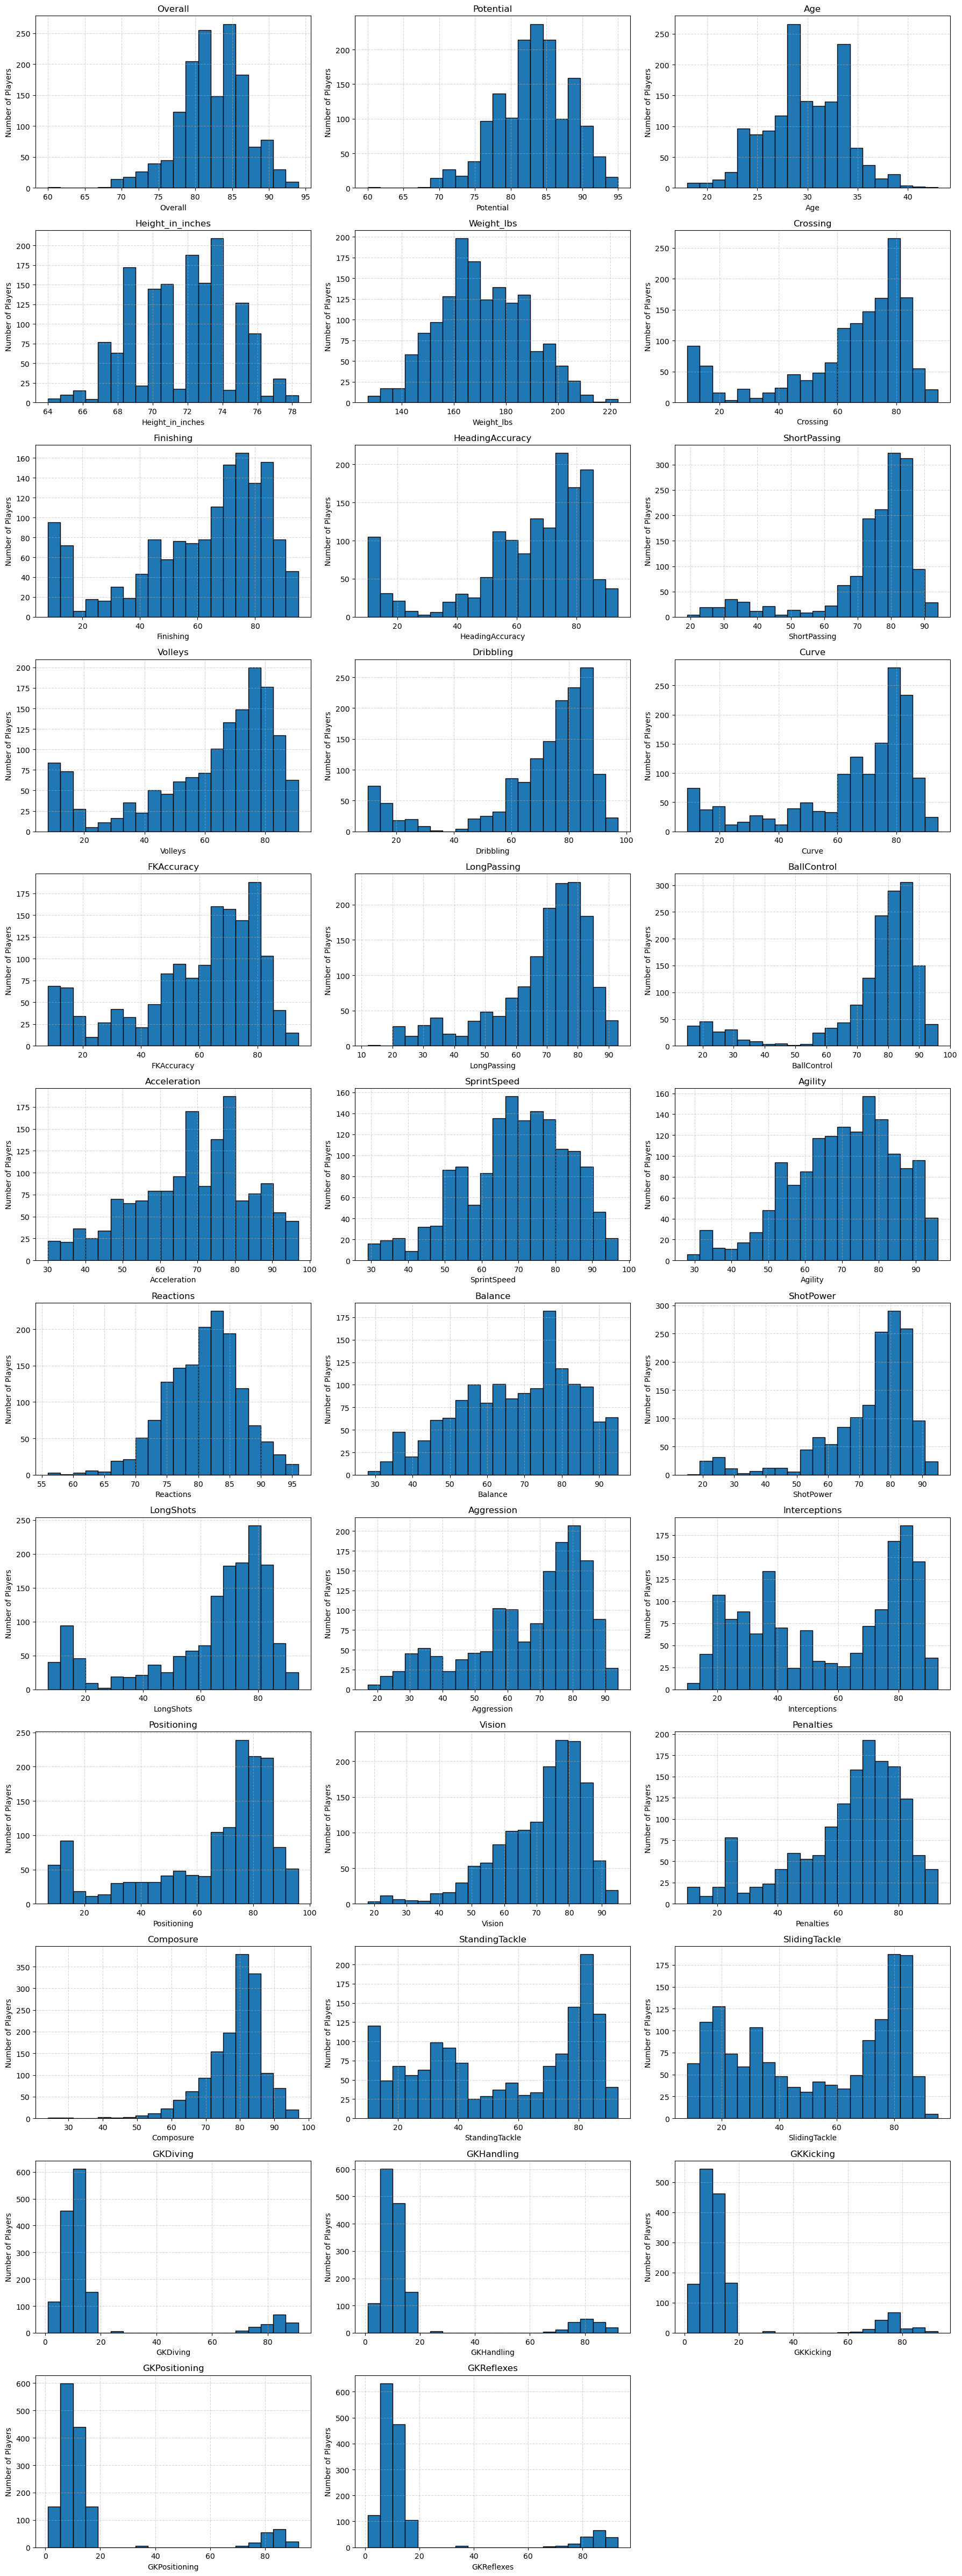

In [20]:
# How many columns per row
cols = 3
# Calculate how many rows we need
rows = math.ceil(len(important_numeric_attributes) / cols)

# Create the subplots grid
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()  # Flatten axes for easy indexing

# Loop through all attributes
for idx, attribute in enumerate(important_numeric_attributes):
    axes[idx].hist(df_cleaned[attribute].dropna(), bins=20, edgecolor='black')
    axes[idx].set_title(attribute)
    axes[idx].set_xlabel(attribute)
    axes[idx].set_ylabel('Number of Players')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

# Hide any unused subplots (in case grid is bigger than needed)
for idx in range(len(important_numeric_attributes), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

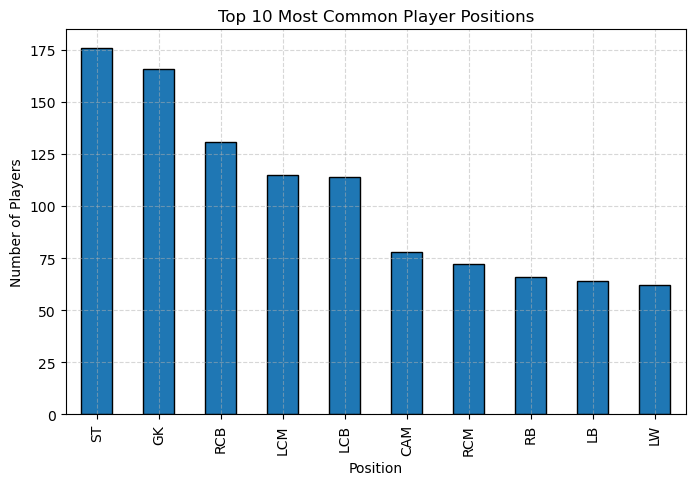

In [21]:
df_cleaned['Position'].value_counts().head(10).plot(kind='bar', figsize=(8,5), edgecolor='black')
plt.title('Top 10 Most Common Player Positions')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

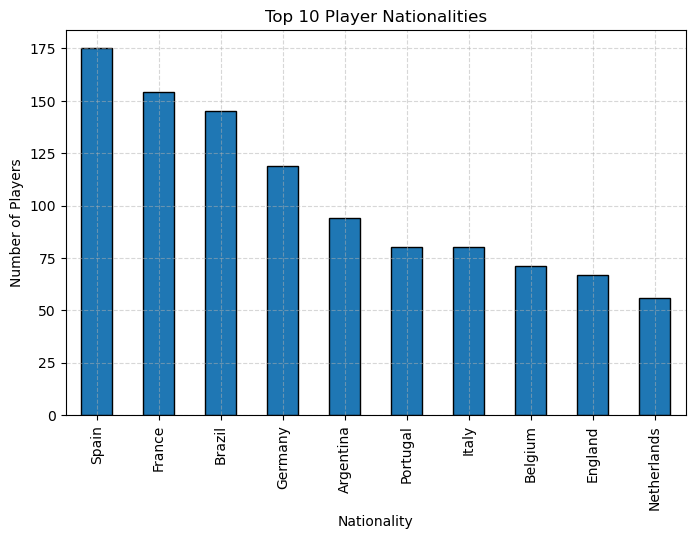

In [22]:
df_cleaned['Nationality'].value_counts().head(10).plot(kind='bar', figsize=(8,5), edgecolor='black')
plt.title('Top 10 Player Nationalities')
plt.xlabel('Nationality')
plt.ylabel('Number of Players')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


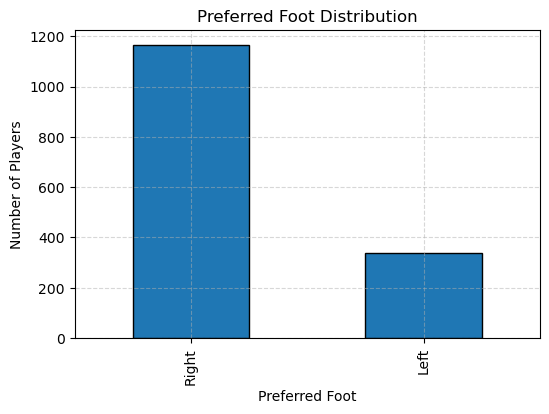

In [23]:
df_cleaned['Preferred Foot'].value_counts().plot(kind='bar', figsize=(6,4), edgecolor='black')
plt.title('Preferred Foot Distribution')
plt.xlabel('Preferred Foot')
plt.ylabel('Number of Players')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [24]:
# Select only numeric columns
numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

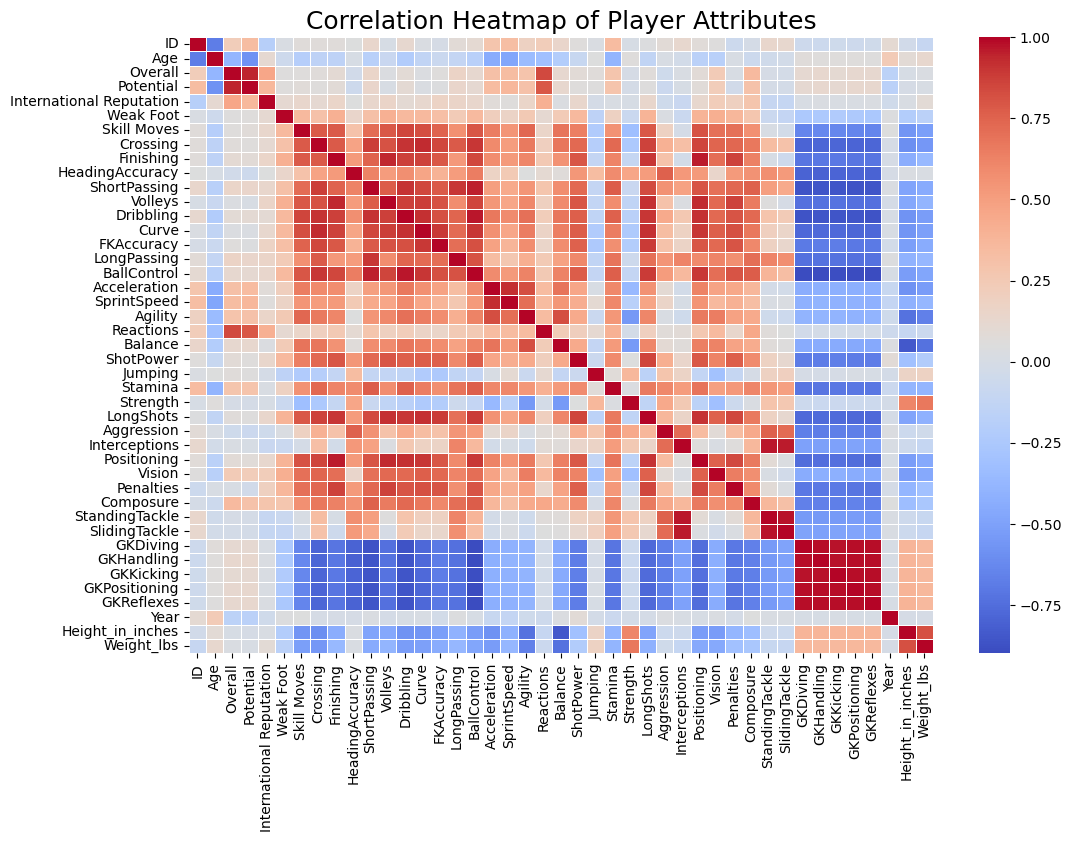

In [25]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Player Attributes', fontsize=18)
plt.show()

In [26]:
# Flatten the correlation matrix
corr_pairs = correlation_matrix.unstack()

# Convert to DataFrame
corr_df = pd.DataFrame(corr_pairs, columns=['Correlation']).reset_index()
corr_df.columns = ['Attribute 1', 'Attribute 2', 'Correlation']

In [27]:
# Drop self-correlations
corr_df = corr_df[corr_df['Attribute 1'] != corr_df['Attribute 2']]

In [28]:
# Sort attribute pairs alphabetically to avoid (A,B) and (B,A) duplicates
corr_df['Pairs'] = list(zip(corr_df['Attribute 1'], corr_df['Attribute 2']))
corr_df['SortedPairs'] = corr_df['Pairs'].apply(lambda x: tuple(sorted(x)))

# Drop duplicates
corr_df = corr_df.drop_duplicates(subset='SortedPairs')

In [29]:
# Add absolute correlation for sorting
corr_df['AbsCorrelation'] = corr_df['Correlation'].abs()

# Sort descending
corr_df = corr_df.sort_values(by='AbsCorrelation', ascending=False)

# View top pairs
corr_df.head(20)

,Attribute 1,Attribute 2,Correlation,Pairs,SortedPairs,AbsCorrelation
1544,GKDiving,GKReflexes,0.984021,"(GKDiving, GKReflexes)","(GKDiving, GKReflexes)",0.984021
1673,GKPositioning,GKReflexes,0.984013,"(GKPositioning, GKReflexes)","(GKPositioning, GKReflexes)",0.984013
1541,GKDiving,GKHandling,0.982103,"(GKDiving, GKHandling)","(GKDiving, GKHandling)",0.982103
1587,GKHandling,GKReflexes,0.981973,"(GKHandling, GKReflexes)","(GKHandling, GKReflexes)",0.981973
1543,GKDiving,GKPositioning,0.981591,"(GKDiving, GKPositioning)","(GKDiving, GKPositioning)",0.981591
1586,GKHandling,GKPositioning,0.981536,"(GKHandling, GKPositioning)","(GKHandling, GKPositioning)",0.981536
1630,GKKicking,GKReflexes,0.979191,"(GKKicking, GKReflexes)","(GKKicking, GKReflexes)",0.979191
1629,GKKicking,GKPositioning,0.977775,"(GKKicking, GKPositioning)","(GKKicking, GKPositioning)",0.977775
1585,GKHandling,GKKicking,0.976292,"(GKHandling, GKKicking)","(GKHandling, GKKicking)",0.976292
1542,GKDiving,GKKicking,0.976182,"(GKDiving, GKKicking)","(GKDiving, GKKicking)",0.976182


## Observations:

- The extremely high correlations (above 0.97) suggest that goalkeeping skills tend to improve or decline together.
- This tight coupling is expected because a goalkeeper's performance depends on a combination of handling, diving, reflexes, positioning, and kicking ability — and these abilities are usually trained and developed together.
- It also implies that, within the FIFA data model, **goalkeeper ratings are very interdependent**, and **individual GK attributes may not be entirely independent predictors** of a goalkeeper’s overall ability.
- When conducting player analyses or dimensionality reduction, it is advisable to **treat GK attributes separately from field player attributes** because goalkeepers form a distinct player cluster both statistically and functionally.

## Practical Implication:

- For future visualizations or modeling, it would be better to **separate goalkeepers from field players** when studying player patterns — to avoid skewing the analysis with this tightly clustered subgroup.

# Key Observations from Correlation Heatmap

## Attribute Relationships:

- **Overall Rating** correlates strongly with:
  - **Reactions**
  - **Composure**
  - **ShortPassing**
  - **BallControl**
  - **Vision**

- **Playmaking attributes** like Dribbling, BallControl, Vision, and ShortPassing are highly correlated among each other.

- **Physical attributes** (Jumping, Strength, Stamina) form a separate group but have **weaker correlation with Overall Rating**.

- **Goalkeeper attributes** (GKHandling, GKDiving, GKPositioning, etc.) are highly correlated with each other, but **separate from field player attributes**.

- **Height and Weight** show **very low correlation** with Overall Rating.
  - Meaning: Being tall or heavy doesn’t necessarily make a player higher-rated.

- **Age** is **mildly negatively correlated** with Potential.
  - Younger players tend to have higher potential.

## Strategic Insights:

- Technical and mental skills (BallControl, Vision, Reactions, Composure) are **strong indicators of a player's Overall Rating**.
- Physical strength matters in gameplay but **less so for rating evaluations**.
- Goalkeepers should be analyzed separately from field players for more meaningful insights.



In [30]:
# Correlations with Overall
overall_corr = correlation_matrix['Overall'].drop('Overall')  # drop self-correlation

# Sort by absolute value (strongest correlations)
overall_corr_sorted = overall_corr.abs().sort_values(ascending=False)
print(overall_corr_sorted.head(10))


Potential                   0.945809
Reactions                   0.839154
International Reputation    0.459432
Age                         0.385607
Composure                   0.351453
SprintSpeed                 0.339307
Acceleration                0.311289
Agility                     0.292717
Stamina                     0.285455
Vision                      0.242204
Name: Overall, dtype: float64


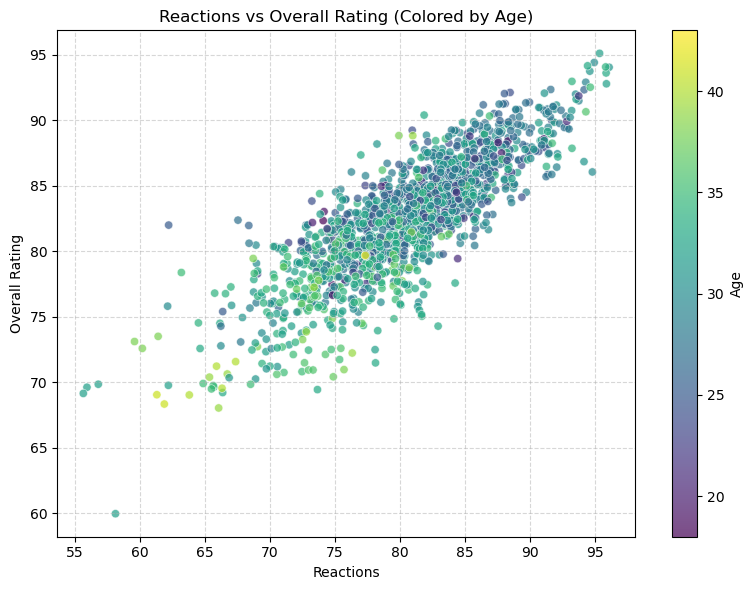

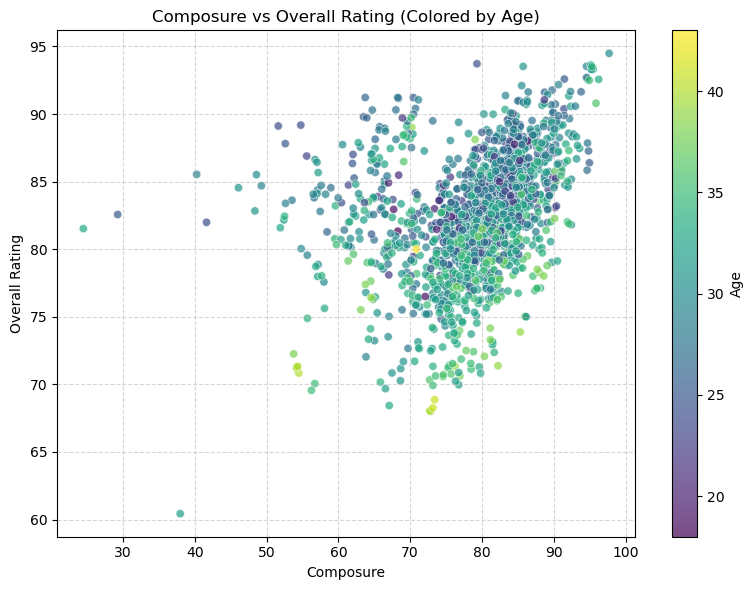

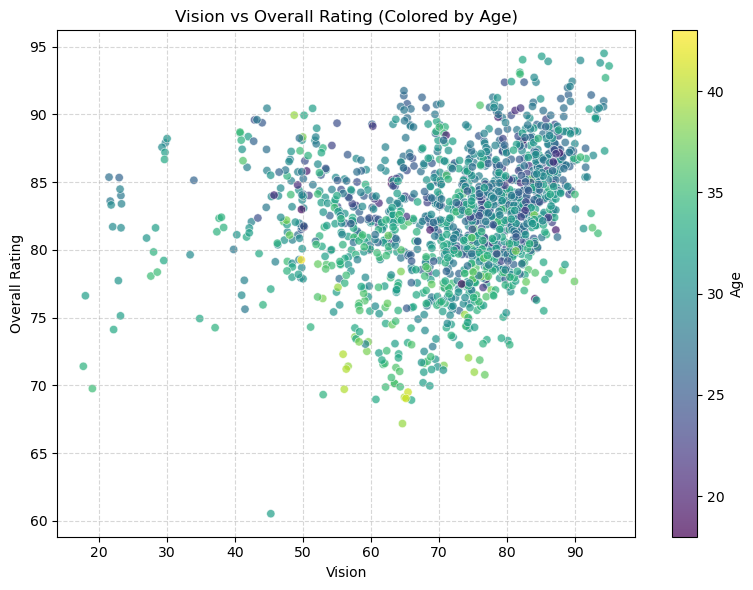

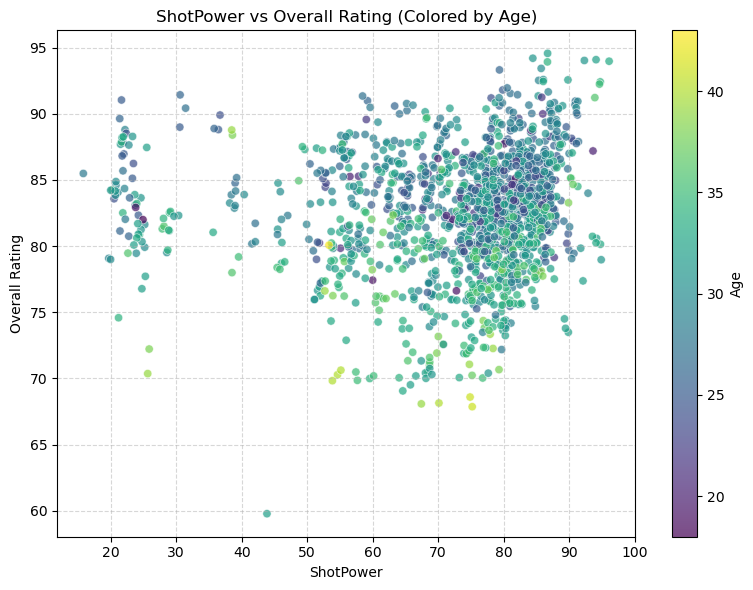

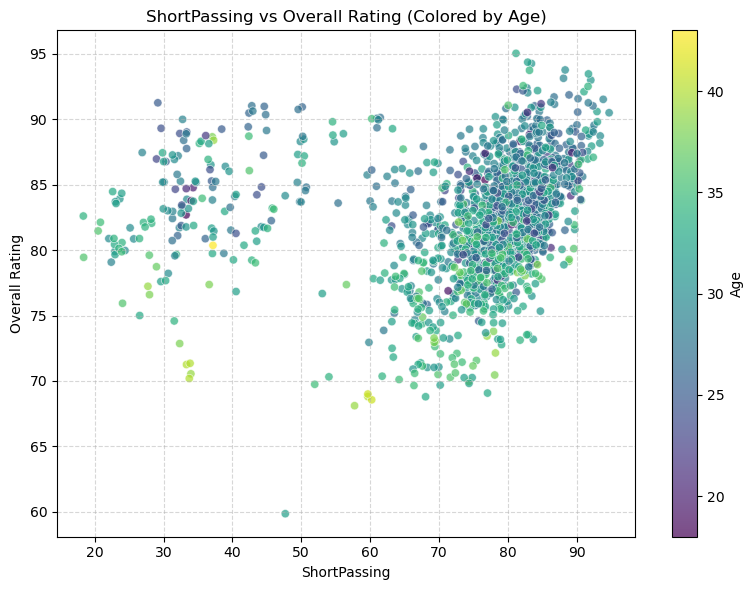

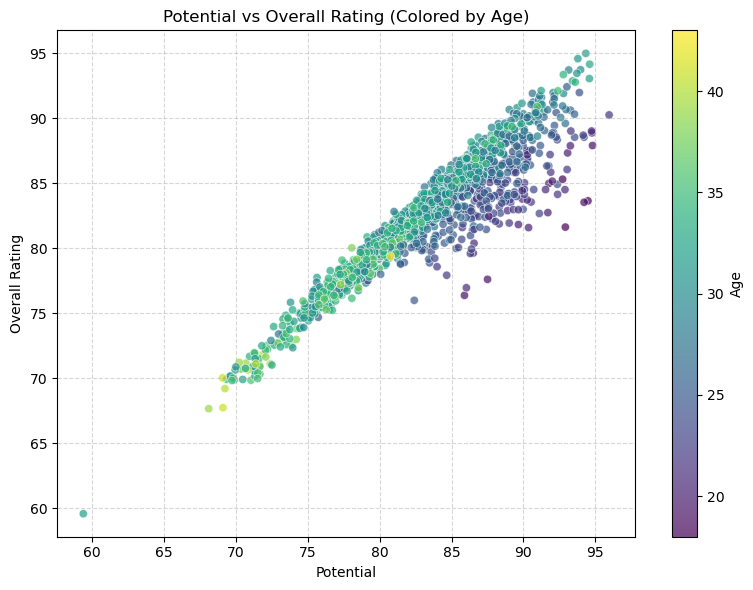

In [31]:
# Focused attributes
focused_attributes = ['Reactions', 'Composure', 'Vision', 'ShotPower', 'ShortPassing', 'Potential']

for attribute in focused_attributes:
    plt.figure(figsize=(8,6))
    
    # Add small random noise (jitter) to X and Y
    x_jitter = df_cleaned[attribute] + np.random.normal(0, 0.5, size=len(df_cleaned))
    y_jitter = df_cleaned['Overall'] + np.random.normal(0, 0.5, size=len(df_cleaned))
    
    scatter = plt.scatter(
        x=x_jitter,
        y=y_jitter,
        c=df_cleaned['Age'],          # Coloring by Age
        cmap='viridis',               # Nice continuous gradient
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5
    )
    
    plt.colorbar(scatter, label='Age')
    plt.title(f'{attribute} vs Overall Rating (Colored by Age)')
    plt.xlabel(attribute)
    plt.ylabel('Overall Rating')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# Key Finding: Impact of Age on Overall Rating

Although young players (typically under 25 years old) often display strong individual attributes — particularly in areas such as Vision, ShotPower, and ShortPassing — they generally do not achieve the highest Overall Ratings.

This is evident from the scatterplots where players aged under 25 (represented by darker colors in the Viridis colormap) are distributed across a wide range of Overall Ratings, even when they possess high scores in key attributes.

This pattern suggests that:

- **Technical ability alone is not sufficient** for a high Overall Rating.
- **Experience, maturity, exposure to high-level competition, and consistency** likely play critical roles in a player’s development.
- **Older players (30+ years)**, even if they have comparable or slightly lower individual stats, tend to cluster more tightly at higher Overall Ratings.
- **Overall Rating appears to capture both technical skill and professional maturity**, not just raw attributes.

In summary, while young players show promise through strong attribute scores, the transition to elite Overall Ratings is influenced by factors beyond pure skill — notably, game sense, tactical awareness, and consistent high-level performance developed over time.


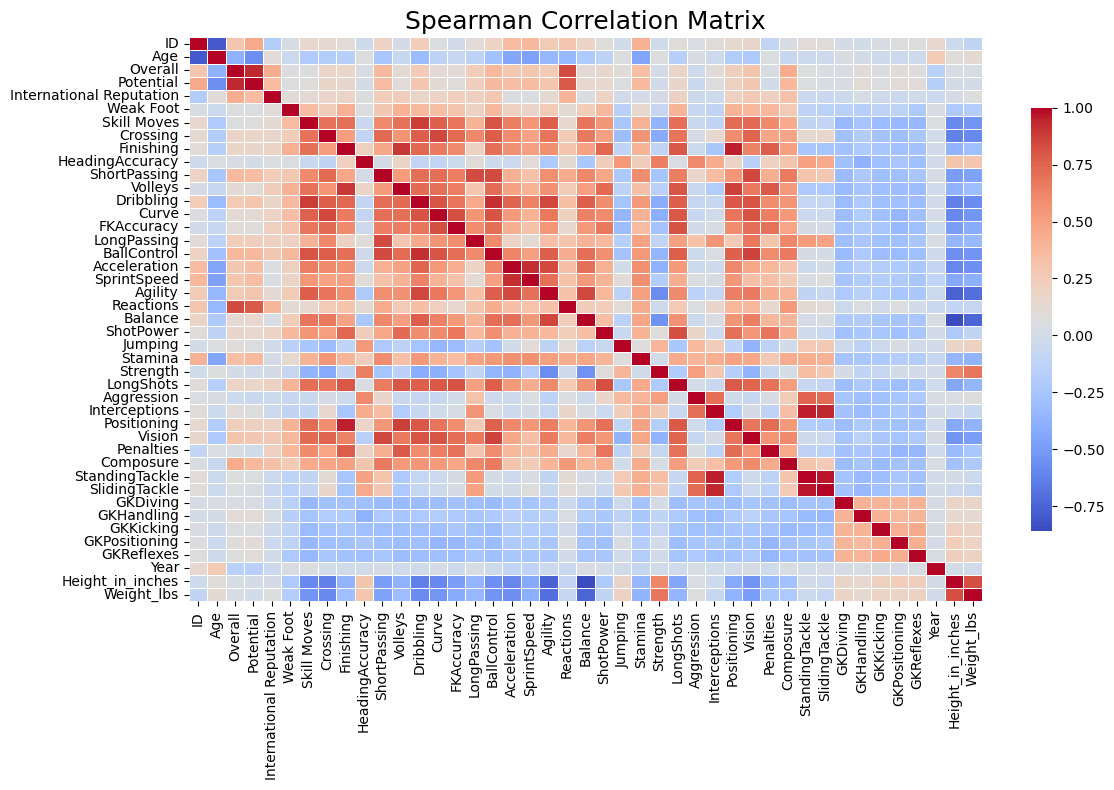

In [32]:
# Calculate Spearman correlation
spearman_corr = df_cleaned.select_dtypes(include=['int64', 'float64']).corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    spearman_corr,
    cmap='coolwarm',
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.75}
)
plt.title('Spearman Correlation Matrix', fontsize=18)
plt.tight_layout()
plt.show()

In [33]:
# First, flatten the correlation matrix
spearman_corr_flat = spearman_corr.unstack()

# Convert to a DataFrame for easy handling
spearman_corr_df = pd.DataFrame(spearman_corr_flat, columns=['Correlation']).reset_index()
spearman_corr_df.columns = ['Attribute 1', 'Attribute 2', 'Correlation']

# Drop self-correlations (where Attribute 1 == Attribute 2)
spearman_corr_df = spearman_corr_df[spearman_corr_df['Attribute 1'] != spearman_corr_df['Attribute 2']]

# Sort by absolute correlation value (highest first)
spearman_corr_df['AbsCorrelation'] = spearman_corr_df['Correlation'].abs()
spearman_corr_df = spearman_corr_df.sort_values(by='AbsCorrelation', ascending=False)

# Optional: Drop duplicate pairs (e.g., (A,B) and (B,A))
spearman_corr_df['Pairs'] = list(zip(spearman_corr_df['Attribute 1'], spearman_corr_df['Attribute 2']))
spearman_corr_df['SortedPairs'] = spearman_corr_df['Pairs'].apply(lambda x: tuple(sorted(x)))
spearman_corr_df = spearman_corr_df.drop_duplicates(subset='SortedPairs')

# Final sorted, clean table
top_correlations = spearman_corr_df[['Attribute 1', 'Attribute 2', 'Correlation']]

# View top 20 correlated pairs
top_correlations.head(40)


,Attribute 1,Attribute 2,Correlation
1495,SlidingTackle,StandingTackle,0.965858
1237,Interceptions,StandingTackle,0.955875
373,Finishing,Positioning,0.951365
131,Potential,Overall,0.938155
1490,SlidingTackle,Interceptions,0.936481
749,Acceleration,SprintSpeed,0.925823
700,BallControl,Dribbling,0.915536
355,Finishing,Volleys,0.893382
522,Dribbling,Skill Moves,0.879974
502,Volleys,Positioning,0.875577


C:\Users\vinay\AppData\Local\Temp\ipykernel_2320\3651435747.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_50['Pair'] = top_50['Attribute 1'] + ' vs ' + top_50['Attribute 2']


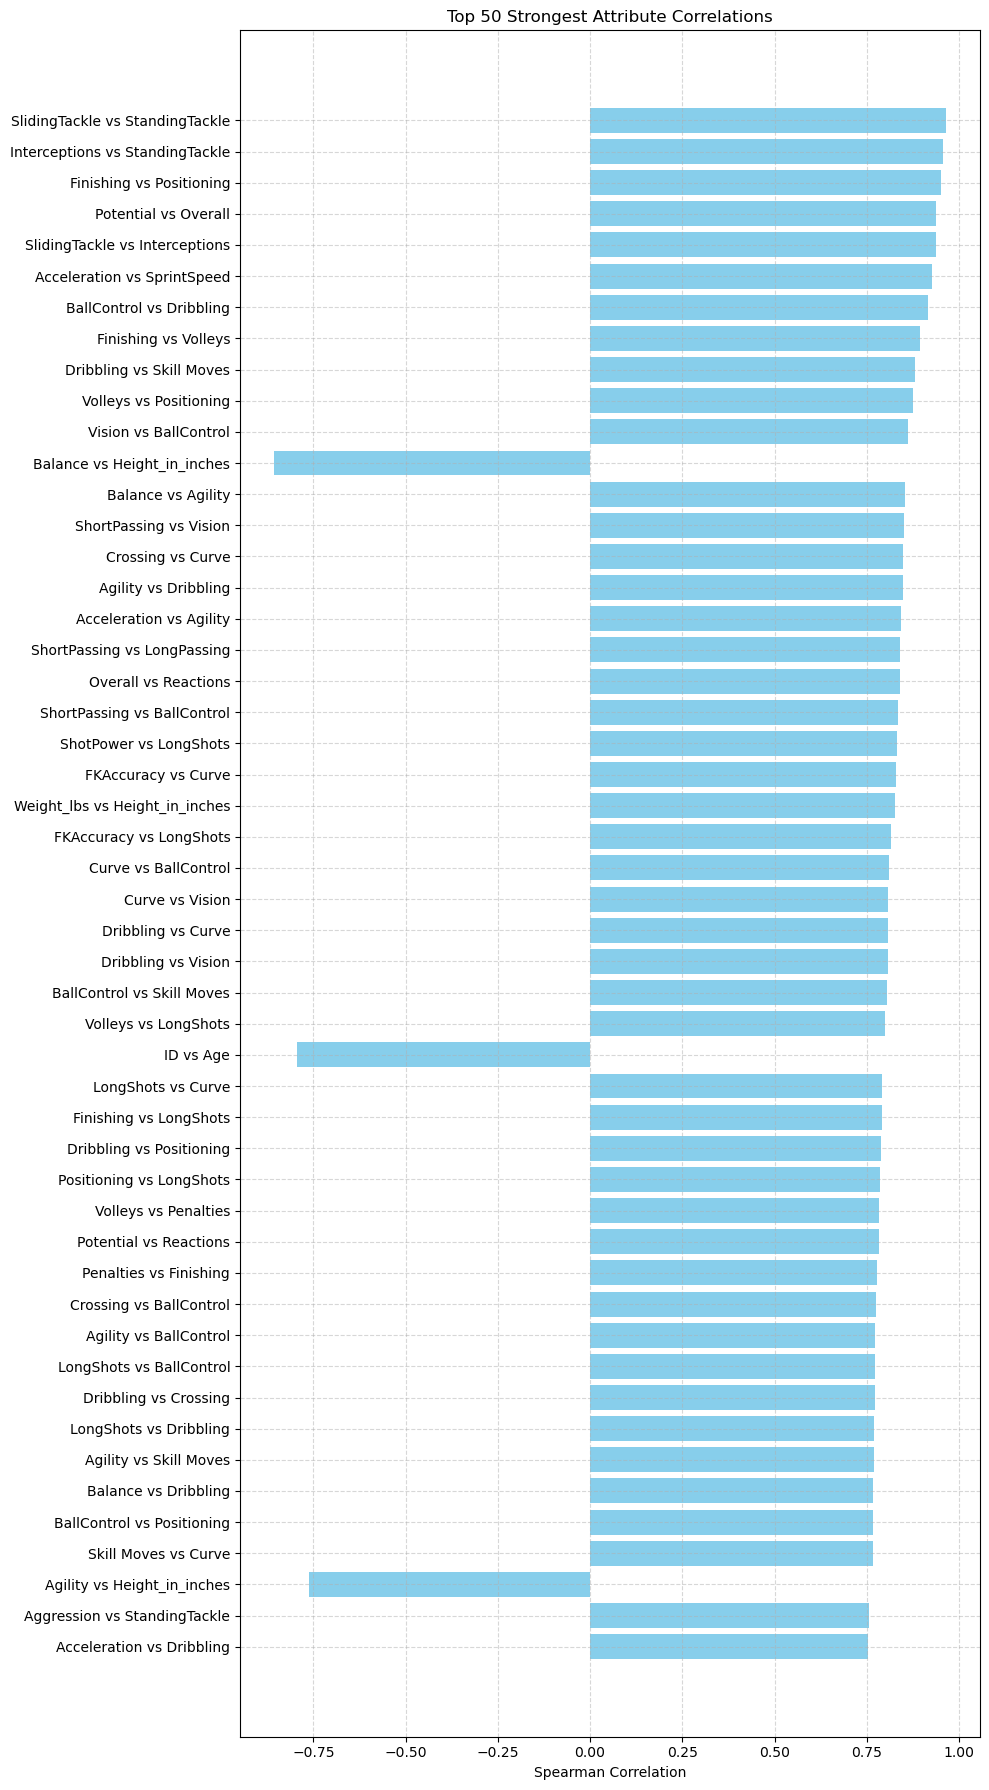

In [34]:
# Take the top 50 correlations
top_50 = top_correlations.head(50)

# Create a label for each pair
top_50['Pair'] = top_50['Attribute 1'] + ' vs ' + top_50['Attribute 2']

# Plot
plt.figure(figsize=(10, 18))
plt.barh(top_50['Pair'], top_50['Correlation'], color='skyblue')
plt.xlabel('Spearman Correlation')
plt.title('Top 50 Strongest Attribute Correlations')
plt.gca().invert_yaxis()  # Highest correlation at the top
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

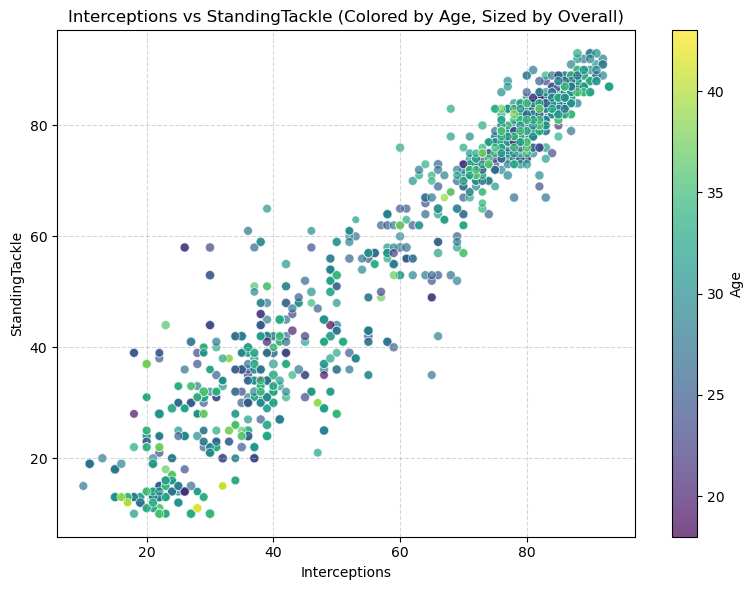

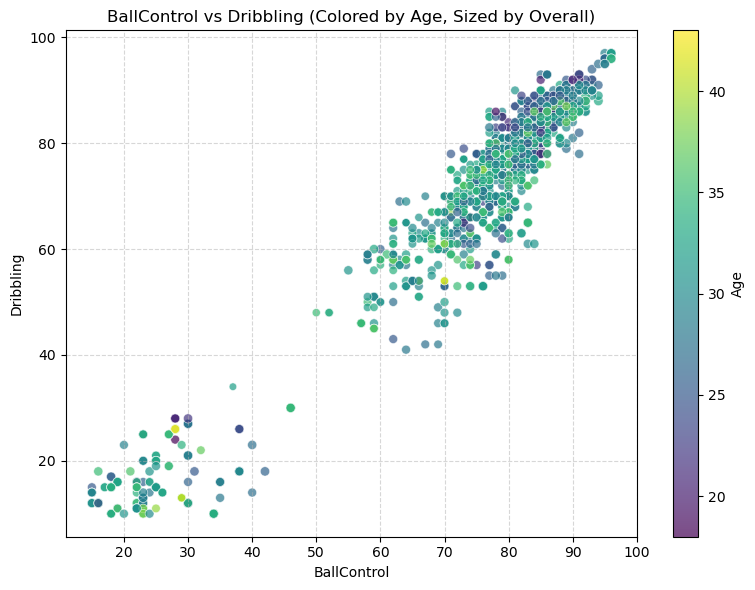

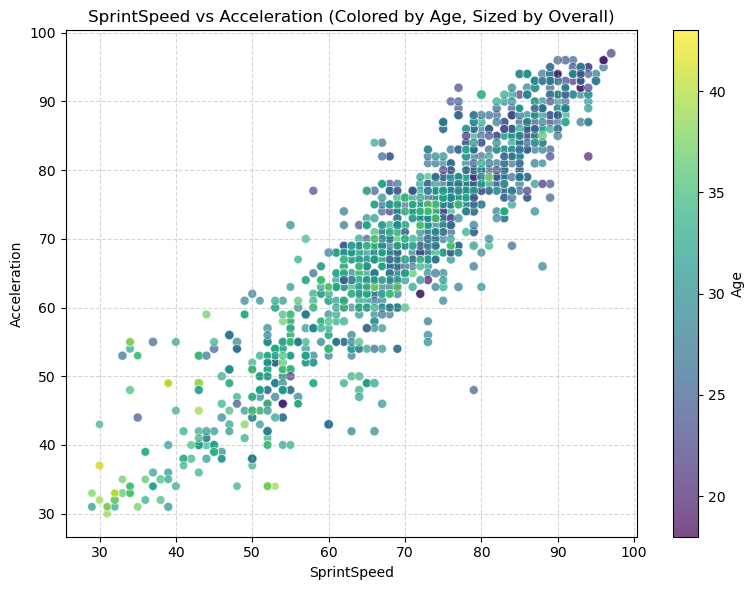

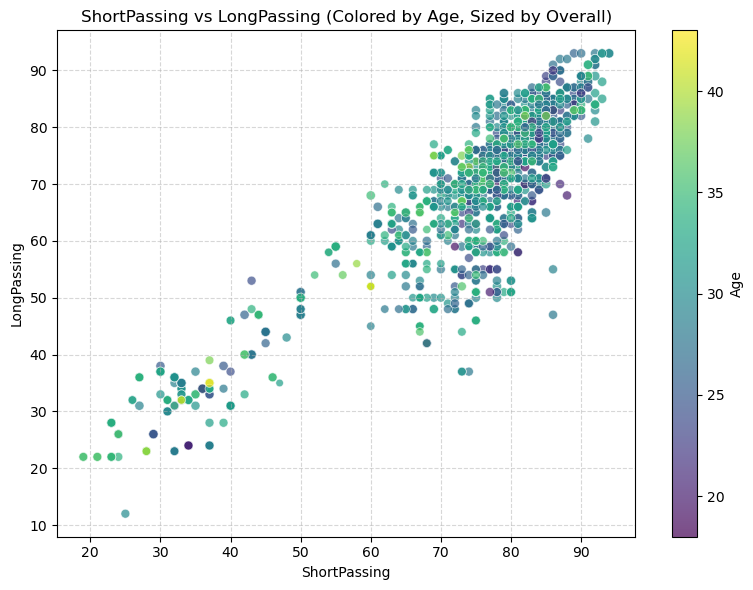

In [44]:
# List of logical pairs
pairs_to_plot = [
    ('Interceptions', 'StandingTackle'),
    ('BallControl', 'Dribbling'),
    ('SprintSpeed', 'Acceleration'),
    ('ShortPassing', 'LongPassing')
]

for x_attr, y_attr in pairs_to_plot:
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        x=df_cleaned[x_attr],
        y=df_cleaned[y_attr],
        c=df_cleaned['Age'],           # Color by Age
        s=df_cleaned['Overall'] / 2,   # Size by Overall (divided by 2 to keep dots reasonable)
        cmap='viridis',
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5
    )
    plt.colorbar(scatter, label='Age')
    plt.title(f'{x_attr} vs {y_attr} (Colored by Age, Sized by Overall)')
    plt.xlabel(x_attr)
    plt.ylabel(y_attr)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [45]:
# Filter for latest year (FIFA 22)
latest_year = df_cleaned['Year'].max()
latest_df = df_cleaned[df_cleaned['Year'] == latest_year]

# Sort by Overall Rating and pick Top 10
top10_players_2022 = latest_df.sort_values(by='Overall', ascending=False).head(10)['Name'].tolist()

In [46]:
# Filter full dataframe for only these players
top10_career_data = df_cleaned[df_cleaned['Name'].isin(top10_players_2022)]

In [47]:
top10_career_data

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
87645,192985,K. De Bruyne,30,Belgium,91,91,Manchester City,€125.5M,€350K,Right,...,65.0,53.0,15.0,13.0,5.0,10.0,13.0,2022,71.259881,154
87671,158023,L. Messi,34,Argentina,93,93,Paris Saint-Germain,€78M,€320K,Left,...,35.0,24.0,6.0,11.0,15.0,14.0,8.0,2022,66.929170,158
87675,188545,R. Lewandowski,32,Poland,92,92,FC Bayern München,€119.5M,€270K,Right,...,42.0,19.0,15.0,6.0,12.0,8.0,10.0,2022,72.834685,178
87678,20801,Cristiano Ronaldo,36,Portugal,91,91,Manchester United,€45M,€270K,Right,...,32.0,24.0,7.0,11.0,15.0,14.0,11.0,2022,73.622087,182
87681,202126,H. Kane,27,England,90,90,Tottenham Hotspur,€129.5M,€240K,Right,...,36.0,38.0,8.0,10.0,11.0,14.0,11.0,2022,74.015788,196
87706,190871,Neymar Jr,29,Brazil,91,91,Paris Saint-Germain,€129M,€270K,Right,...,32.0,29.0,9.0,9.0,15.0,15.0,11.0,2022,68.897675,149
87713,215914,N. Kanté,30,France,90,90,Chelsea,€100M,€230K,Right,...,93.0,86.0,15.0,12.0,10.0,7.0,10.0,2022,66.141768,154
87724,231747,K. Mbappé,22,France,91,95,Paris Saint-Germain,€194M,€230K,Right,...,34.0,32.0,13.0,5.0,7.0,11.0,6.0,2022,71.653582,160
101532,192448,M. ter Stegen,29,Germany,90,92,FC Barcelona,€99M,€250K,Right,...,13.0,10.0,88.0,85.0,88.0,88.0,90.0,2022,73.622087,187
101886,200389,J. Oblak,28,Slovenia,91,93,Atlético de Madrid,€112M,€130K,Right,...,12.0,18.0,87.0,92.0,78.0,90.0,90.0,2022,74.015788,191


In [48]:
df_cleaned.columns = df_cleaned.columns.str.lower()

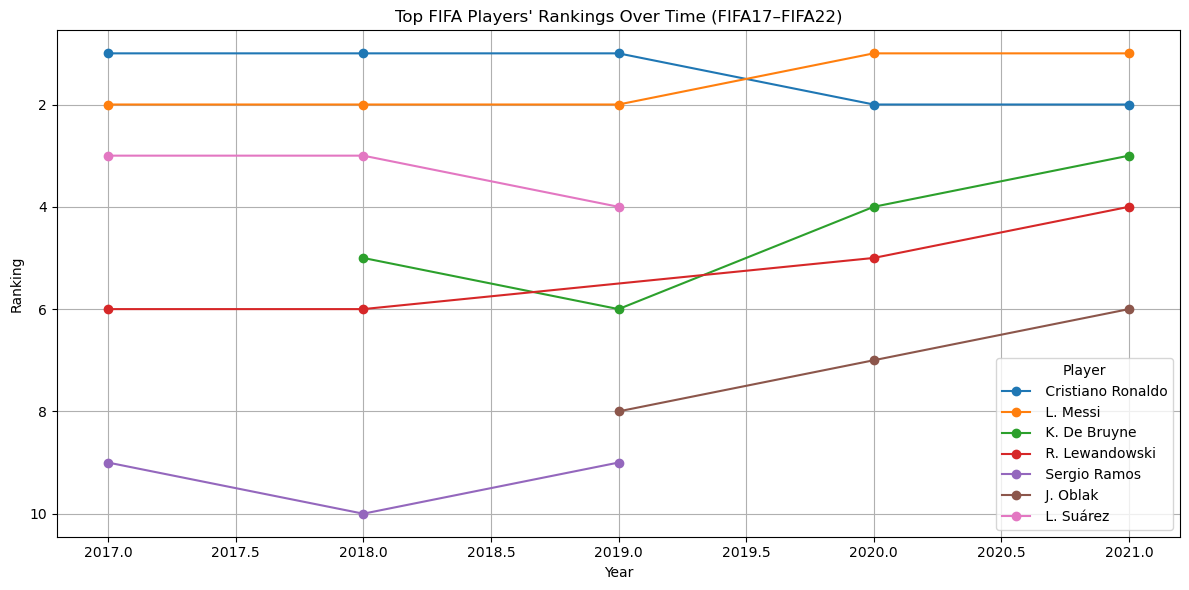

In [49]:
# Load dataset again and ensure consistency
df_cleaned.columns = df_cleaned.columns.str.lower()

# Keep only relevant columns
top_players_df = df_cleaned[['name', 'overall', 'year']].dropna()

# Rank players by overall rating each year
top_per_year = (
    top_players_df.sort_values(['year', 'overall'], ascending=[True, False])
    .groupby('year')
    .head(10)  # Top 10 players per year
)

# Pivot to prepare for bump chart style plot
pivot_df = top_per_year.copy()
pivot_df['rank'] = pivot_df.groupby('year')['overall'].rank(ascending=False, method='first')
pivot_df = pivot_df.sort_values(['name', 'year'])

# Select most frequently top-ranked players
top_names = pivot_df['name'].value_counts().head(7).index.tolist()
pivot_df = pivot_df[pivot_df['name'].isin(top_names)]

# Plot: Bump chart
plt.figure(figsize=(12, 6))
for name in top_names:
    player_data = pivot_df[pivot_df['name'] == name]
    plt.plot(player_data['year'], player_data['rank'], marker='o', label=name)

plt.gca().invert_yaxis()  # Rank 1 should be at the top
plt.title("Top FIFA Players' Rankings Over Time (FIFA17–FIFA22)")
plt.xlabel("Year")
plt.ylabel("Ranking")
plt.legend(title="Player")
plt.grid(True)
plt.tight_layout()
plt.show()


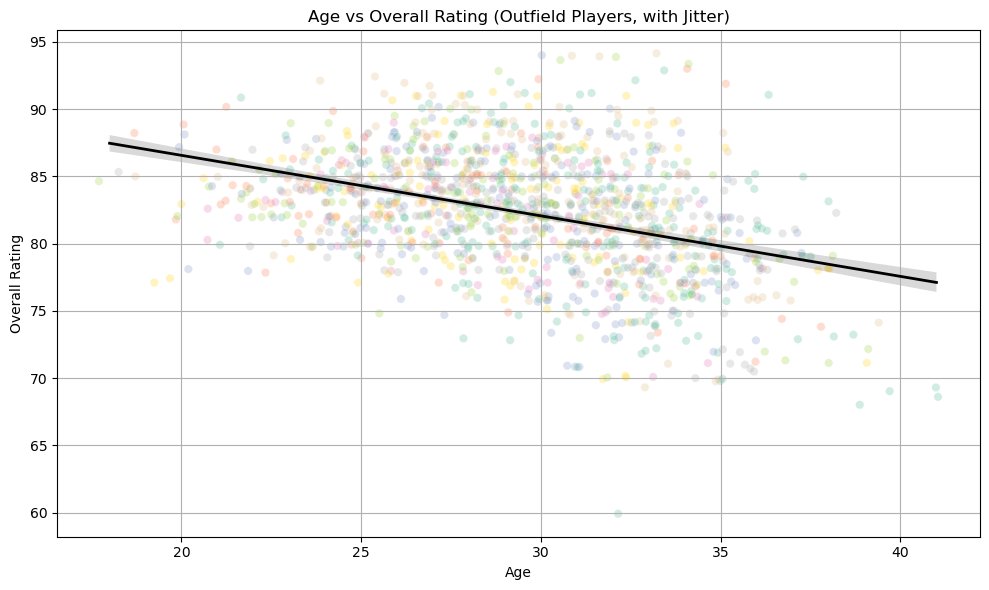

In [69]:
# Ensure relevant columns exist
df_age_rating = df_cleaned[['age', 'overall', 'position']].dropna()

# Focus on common outfield positions only (exclude goalkeepers for clarity)
non_gk_df = df_age_rating[~df_age_rating['position'].isin(['GK'])].copy()

# Add jitter to age and overall
np.random.seed(42)  # for reproducibility
non_gk_df['age_jitter'] = non_gk_df['age'] + np.random.normal(0, 0.3, size=len(non_gk_df))
non_gk_df['overall_jitter'] = non_gk_df['overall'] + np.random.normal(0, 0.2, size=len(non_gk_df))

# Plot: Age vs Overall Rating with jitter and regression trendline
plt.figure(figsize=(10, 6))
sns.scatterplot(data=non_gk_df, x='age_jitter', y='overall_jitter', alpha=0.3, hue='position', palette='Set2', legend=False)
sns.regplot(data=non_gk_df, x='age', y='overall', scatter=False, color='black', line_kws={"linewidth": 2})
plt.title('Age vs Overall Rating (Outfield Players, with Jitter)')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.grid(True)
plt.tight_layout()
plt.show()


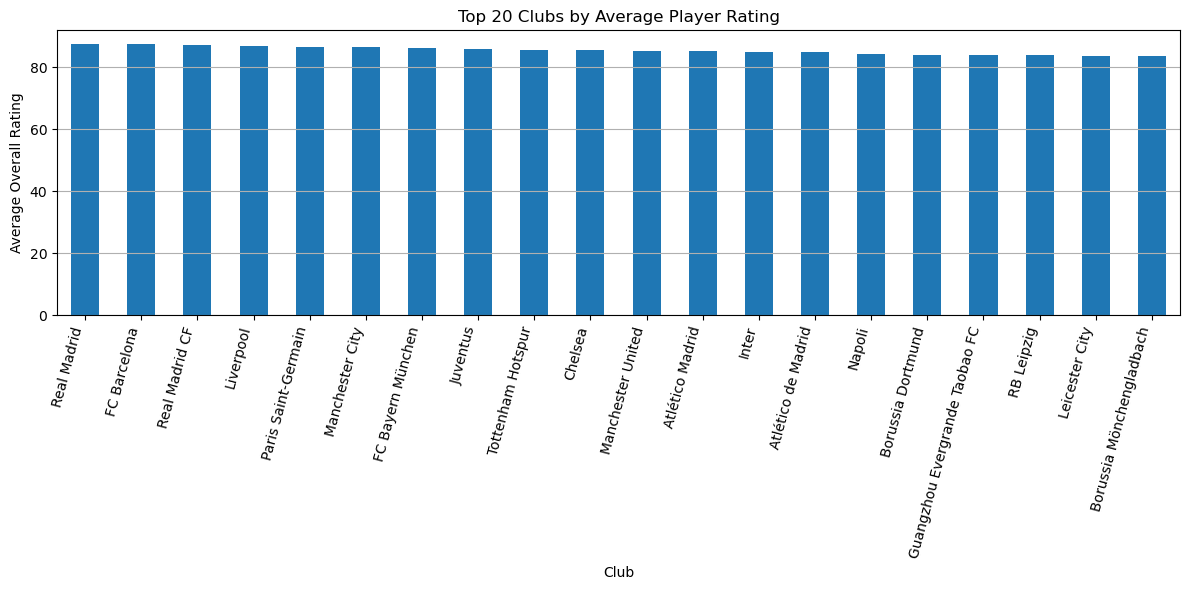

In [51]:
# Check club and overall rating columns
df_club_rating = df_cleaned[['club', 'overall']].dropna()

# Compute average player rating per club
club_avg_rating = df_club_rating.groupby('club')['overall'].mean().sort_values(ascending=False).head(20)

# Plot: Bar chart of average player ratings by club
plt.figure(figsize=(12, 6))
club_avg_rating.plot(kind='bar')
plt.title('Top 20 Clubs by Average Player Rating')
plt.xlabel('Club')
plt.ylabel('Average Overall Rating')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [52]:
# Replace 'England' with 'United Kingdom' to match Plotly's country names
country_counts = (
    df_cleaned['nationality']
    .replace({'England': 'United Kingdom'})
    .value_counts()
    .reset_index()
)
country_counts.columns = ['country', 'num_players']

# Interactive Choropleth Map using Plotly Express
fig = px.choropleth(
    country_counts,
    locations="country",
    locationmode="country names",
    color="num_players",
    hover_name="country",
    color_continuous_scale="Hot_r",
    title="Interactive World Map: Number of FIFA Players by Country"
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()


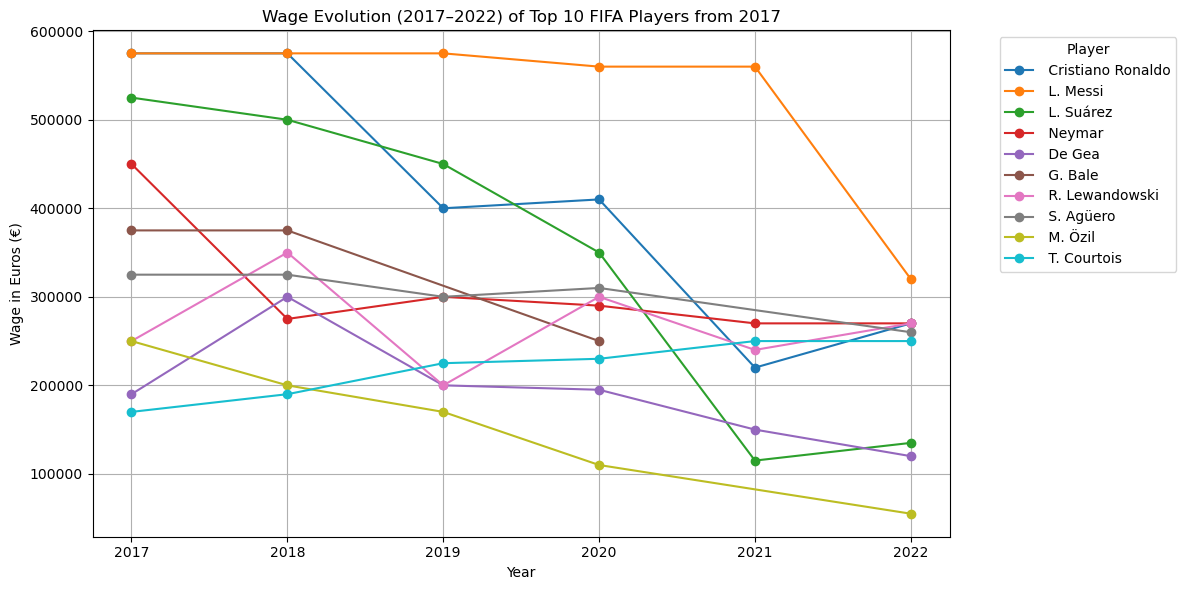

In [53]:
# Step 1: Convert 'wage' strings (like '€522K') to float in euros
def parse_wage(wage_str):
    if isinstance(wage_str, str):
        wage_str = wage_str.replace('€', '').strip()
        if 'K' in wage_str:
            return float(wage_str.replace('K', '')) * 1_000
        elif 'M' in wage_str:
            return float(wage_str.replace('M', '')) * 1_000_000
    return None

df_cleaned['wage_eur'] = df_cleaned['wage'].apply(parse_wage)

# Step 2: Get top 10 players in 2017 by overall rating using unique ID
top10_2017_ids = (
    df_cleaned[df_cleaned['year'] == 2017]
    .sort_values(by='overall', ascending=False)
    .drop_duplicates(subset='id')
    .head(10)[['id', 'name']]
)

top10_ids = top10_2017_ids['id'].tolist()

# Step 3: Get all their records between 2017 and 2022
df_top10_id = df_cleaned[
    (df_cleaned['id'].isin(top10_ids)) &
    (df_cleaned['year'].between(2017, 2022))
]

# Step 4: Plot wage evolution for each player
plt.figure(figsize=(12, 6))
for pid in top10_ids:
    player_data = df_top10_id[df_top10_id['id'] == pid]
    player_name = top10_2017_ids[top10_2017_ids['id'] == pid]['name'].values[0]
    plt.plot(player_data['year'], player_data['wage_eur'], marker='o', label=player_name)

plt.title("Wage Evolution (2017–2022) of Top 10 FIFA Players from 2017")
plt.xlabel("Year")
plt.ylabel("Wage in Euros (€)")
plt.legend(title="Player", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


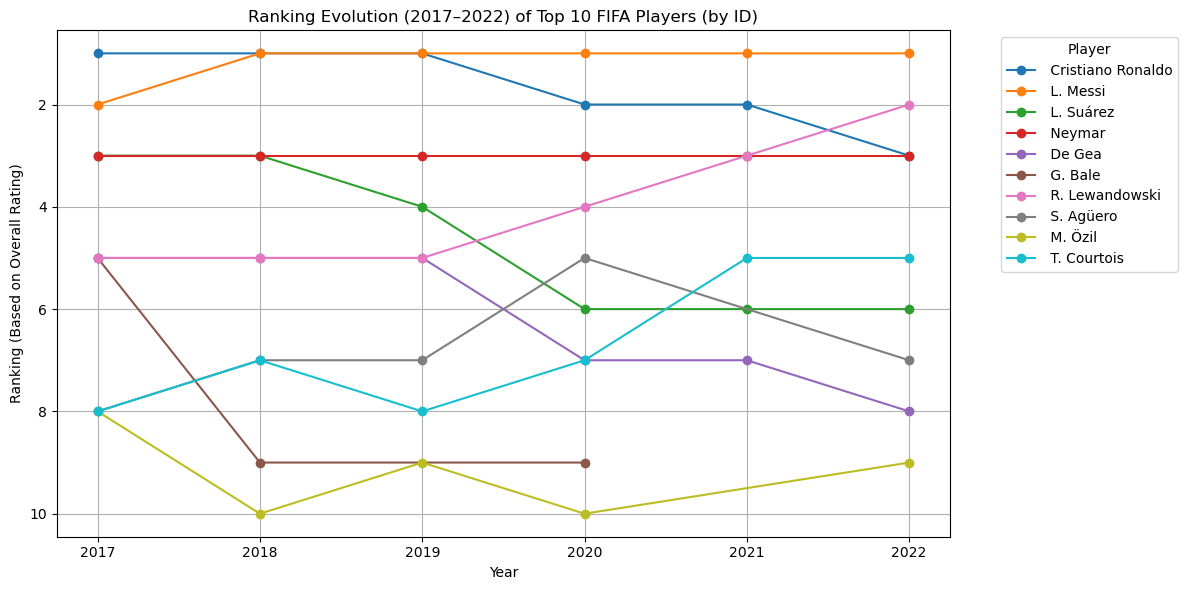

In [54]:
# Rank players by overall each year, but only for the top 10 from 2017 (by ID)
df_ranked = df_cleaned[df_cleaned['id'].isin(top10_ids) & df_cleaned['year'].between(2017, 2022)].copy()

# Create rankings for these players across years (lower rank = higher rating)
df_ranked['rank'] = df_ranked.groupby('year')['overall'].rank(ascending=False, method='min')

# Plot ranking evolution for each player (by ID)
plt.figure(figsize=(12, 6))
for pid in top10_ids:
    player_data = df_ranked[df_ranked['id'] == pid]
    player_name = top10_2017_ids[top10_2017_ids['id'] == pid]['name'].values[0]
    plt.plot(player_data['year'], player_data['rank'], marker='o', label=player_name)

plt.gca().invert_yaxis()  # Rank 1 on top
plt.title("Ranking Evolution (2017–2022) of Top 10 FIFA Players (by ID)")
plt.xlabel("Year")
plt.ylabel("Ranking (Based on Overall Rating)")
plt.legend(title="Player", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


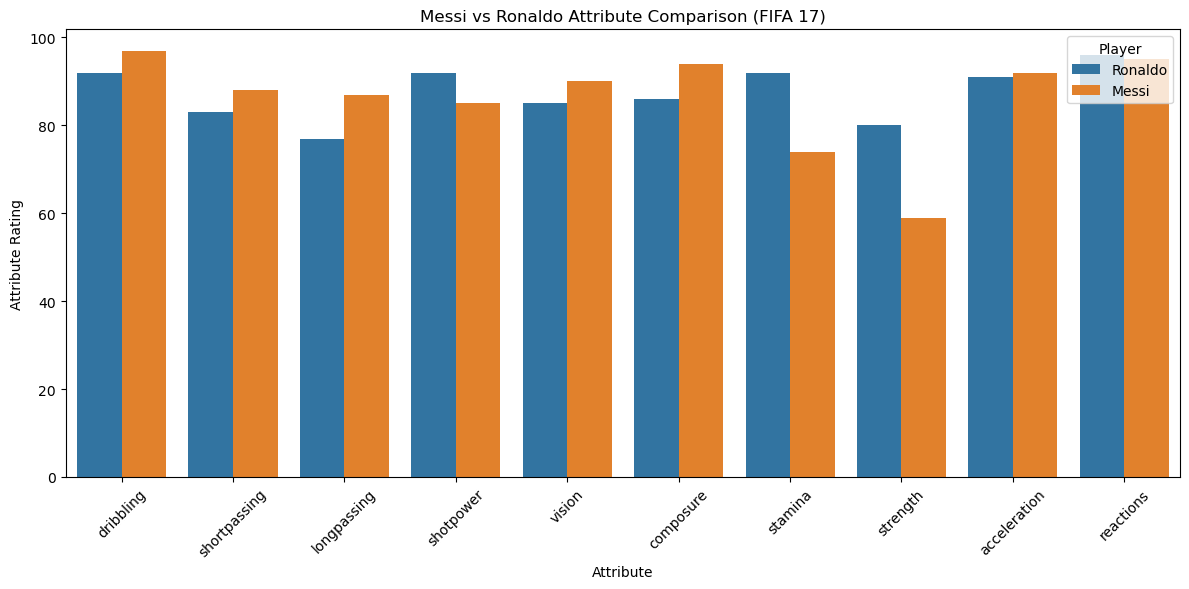

In [70]:
# Filter data for Messi and Ronaldo in 2018
ronaldo_2017 = df_cleaned[(df_cleaned['name'].str.contains("Ronaldo")) & (df_cleaned['year'] == 2017)].iloc[0]
messi_2017 = df_cleaned[(df_cleaned['name'].str.contains("Messi")) & (df_cleaned['year'] == 2017)].iloc[0]

# Attributes to compare (you can customize this list)
attributes = ['dribbling', 'shortpassing', 'longpassing', 'shotpower',
              'vision', 'composure', 'stamina', 'strength', 'acceleration', 'reactions']

# Extract stats for both players
ronaldo_stats = ronaldo_2017[attributes]
messi_stats = messi_2017[attributes]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Attribute': attributes,
    'Ronaldo': ronaldo_stats.values,
    'Messi': messi_stats.values
})

# Melt for seaborn plotting
comparison_melted = comparison_df.melt(id_vars='Attribute', var_name='Player', value_name='Rating')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x='Attribute', y='Rating', hue='Player')
plt.title("Messi vs Ronaldo Attribute Comparison (FIFA 17)")
plt.ylabel("Attribute Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

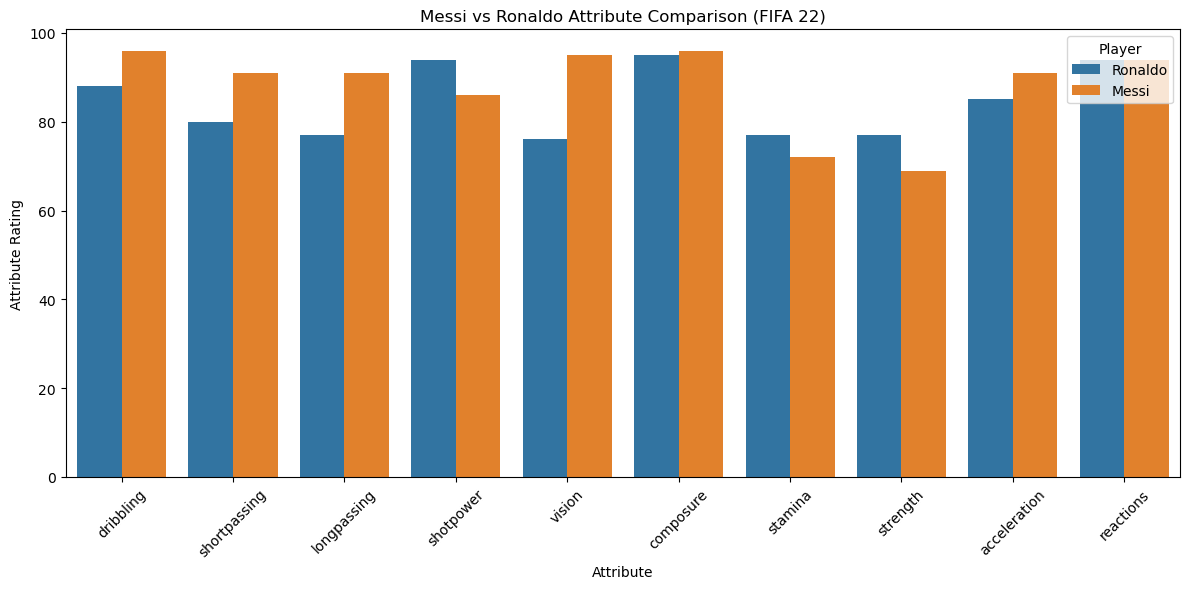

In [56]:
# Filter data for Messi and Ronaldo in 2022
ronaldo_2022 = df_cleaned[(df_cleaned['name'].str.contains("Ronaldo")) & (df_cleaned['year'] == 2022)].iloc[0]
messi_2022 = df_cleaned[(df_cleaned['name'].str.contains("Messi")) & (df_cleaned['year'] == 2022)].iloc[0]

# Extract stats for both players
ronaldo_stats = ronaldo_2022[attributes]
messi_stats = messi_2022[attributes]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Attribute': attributes,
    'Ronaldo': ronaldo_stats.values,
    'Messi': messi_stats.values
})

# Melt for seaborn plotting
comparison_melted = comparison_df.melt(id_vars='Attribute', var_name='Player', value_name='Rating')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x='Attribute', y='Rating', hue='Player')
plt.title("Messi vs Ronaldo Attribute Comparison (FIFA 22)")
plt.ylabel("Attribute Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

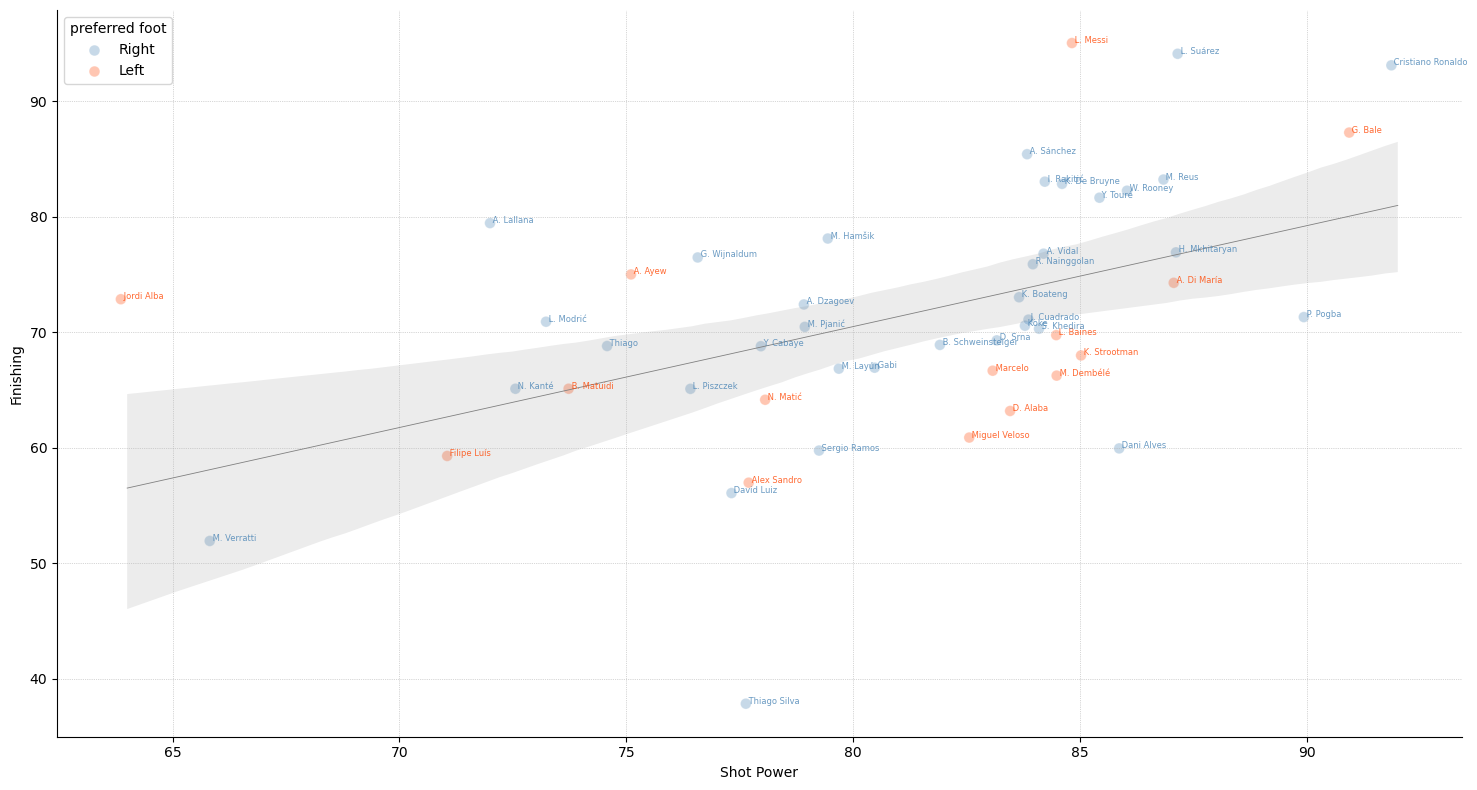

In [94]:
# Filter for relevant columns
kor = df_cleaned[['name', 'shotpower', 'finishing', 'preferred foot']].head(50)

# Calculate Spearman correlation
corr, pval = spearmanr(kor['shotpower'], kor['finishing'])

# Add jitter
np.random.seed(42)
kor['shotpower_jitter'] = kor['shotpower'] + np.random.normal(0, 0.3, len(kor))
kor['finishing_jitter'] = kor['finishing'] + np.random.normal(0, 0.3, len(kor))

# Set plot size
plt.figure(figsize=(15, 8))

# Plot jittered points
palette = {"Left": "orangered", "Right": "steelblue"}
sns.scatterplot(data=kor, x='shotpower_jitter', y='finishing_jitter', hue='preferred foot',
                palette=palette, alpha=0.3, s=60, legend=True)

# Plot player labels
for _, row in kor.iterrows():
    plt.text(row['shotpower_jitter'], row['finishing_jitter'], row['name'], fontsize=6,
             color=palette.get(row['preferred foot'], 'black'), alpha=0.8)

# Plot regression line (without confidence interval)
sns.regplot(data=kor, x='shotpower', y='finishing', scatter=False, color='gray', line_kws={"linewidth": 0.6})

# Title and labels
# plt.title(f"Spearman Correlation Coefficient: {corr:.2f}", fontsize=14, loc='left')
# plt.suptitle("p-value < 0.05" if pval < 0.05 else f"p-value = {pval:.3f}", x=0.12, y=0.92, fontsize=10)
plt.xlabel("Shot Power")
plt.ylabel("Finishing")
plt.grid(True, which='major', linestyle=':', linewidth=0.5)
sns.despine()
plt.tight_layout()
plt.show()


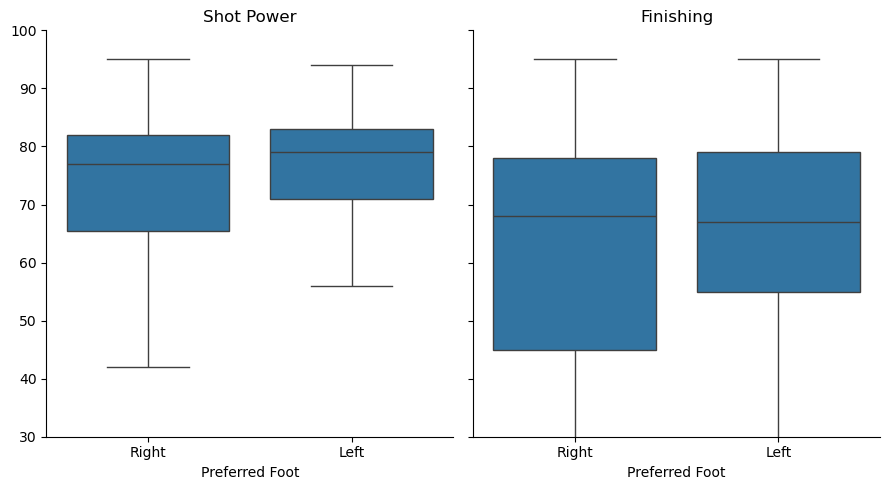

In [102]:
# Filter required data
kor = df_cleaned[['preferred foot', 'shotpower', 'finishing']].dropna()

# Set up side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

# Shared properties
palette = {"Left": "orangered", "Right": "steelblue"}

# Boxplot: Shot Power
sns.boxplot(data=kor, x='preferred foot', y='shotpower', ax=axes[0],
            showfliers=False)
axes[0].set_title("Shot Power")
axes[0].set_ylim(30, 100)
axes[0].set_xlabel("Preferred Foot")
axes[0].set_ylabel("")

# Boxplot: Finishing
sns.boxplot(data=kor, x='preferred foot', y='finishing', ax=axes[1],
            showfliers=False)
axes[1].set_title("Finishing")
axes[1].set_ylim(30, 100)
axes[1].set_xlabel("Preferred Foot")
axes[1].set_ylabel("")

# Minimal theme
sns.despine()
plt.tight_layout()
plt.show()